# 0)Library Loading

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import Design as ds

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler, QuantileTransformer, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1)Dataset Loading

In [2]:
path = 'Telco-Customer-Churn.csv'
df = pd.read_csv(path)
pd.set_option('display.max_columns', None)
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5312,9564-KCLHR,Male,0,No,No,1,Yes,No,DSL,No,No,No,Yes,No,No,Month-to-month,No,Mailed check,51.25,51.25,Yes
1826,6908-VVYHM,Male,0,Yes,No,65,Yes,Yes,Fiber optic,No,Yes,No,No,No,Yes,Month-to-month,Yes,Electronic check,90.65,5931,No
5026,1401-FTHFQ,Male,0,Yes,Yes,23,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Credit card (automatic),20.00,445.3,No
4624,0325-XBFAC,Male,0,No,No,8,Yes,No,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.70,740.3,Yes
4758,3646-ITDGM,Female,0,No,No,56,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.70,1051.9,No


# 2)Preprocessing

## 2_1_Data understanding

ColumnName,Description,Distribution,DataType,count,Distinct,UniqueValues,Missings,MissingPercent,mean,Mode,median,std,min,25%,50%,75%,max
gender,جنسیت مشتری,,Categorical,7043,"Female, Male",2,0,0.00 %,nan,Male,nan,nan,nan,nan,nan,nan,nan
SeniorCitizen,آیا مشتری سالمند است؟ (0/1),,Categorical,7043,"0, 1",2,0,0.00 %,nan,0,nan,nan,nan,nan,nan,nan,nan
Partner,آیا مشتری همسر یا شریک دارد؟,,Categorical,7043,"Yes, No",2,0,0.00 %,nan,No,nan,nan,nan,nan,nan,nan,nan
Dependents,آیا مشتری فرد وابسته دارد؟,,Categorical,7043,"No, Yes",2,0,0.00 %,nan,No,nan,nan,nan,nan,nan,nan,nan
tenure,مدت زمان عضویت مشتری بر حسب ماه,,Numerical,7043,Continuous,73,0,0.00 %,32.37,1,29.00,24.56,0.00,9.00,29.00,55.00,72.00
PhoneService,آیا مشتری سرویس تلفن دارد؟,,Categorical,7043,"No, Yes",2,0,0.00 %,nan,Yes,nan,nan,nan,nan,nan,nan,nan
MultipleLines,آیا مشتری چند خط تلفن دارد؟,,Categorical,7043,"No phone service, No, Yes",3,0,0.00 %,nan,No,nan,nan,nan,nan,nan,nan,nan
InternetService,نوع سرویس اینترنت مشتری,,Categorical,7043,"DSL, Fiber optic, No",3,0,0.00 %,nan,Fiber optic,nan,nan,nan,nan,nan,nan,nan
OnlineSecurity,آیا مشتری سرویس امنیت آنلاین دارد؟,,Categorical,7043,"No, Yes, No internet service",3,0,0.00 %,nan,No,nan,nan,nan,nan,nan,nan,nan
OnlineBackup,آیا مشتری سرویس پشتیبان‌گیری آنلاین دارد؟,,Categorical,7043,"Yes, No, No internet service",3,0,0.00 %,nan,No,nan,nan,nan,nan,nan,nan,nan

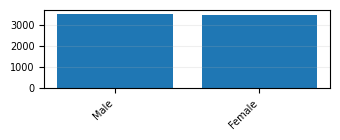
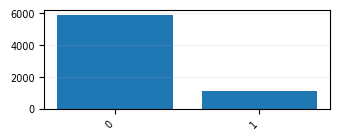
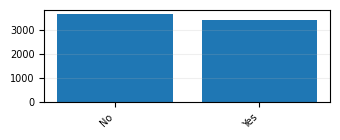
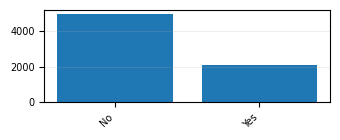
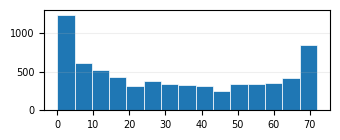
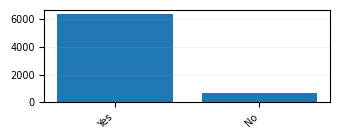
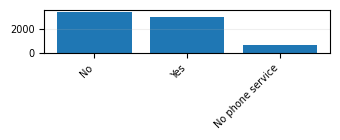
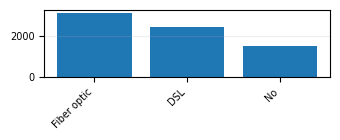
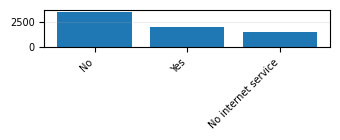
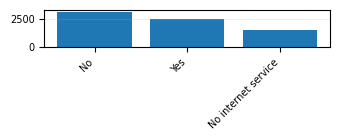
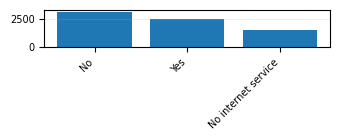
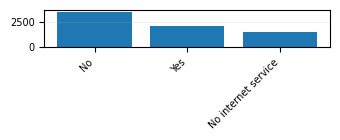
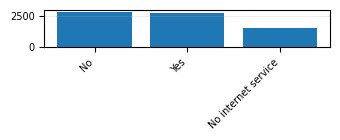
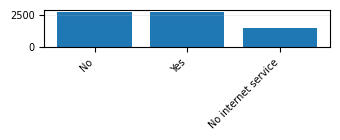
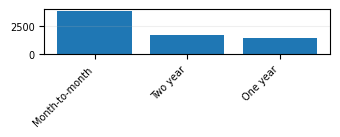
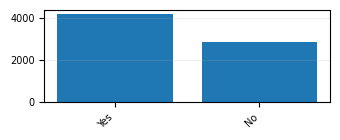
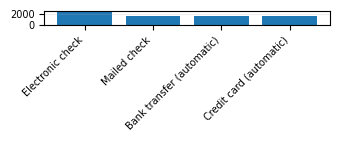
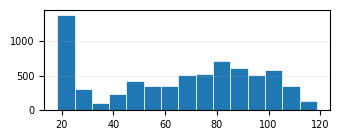
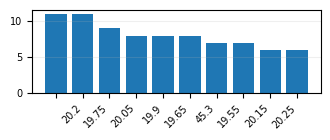
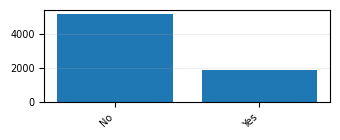

In [3]:
description = [
    "جنسیت مشتری",
    "آیا مشتری سالمند است؟ (0/1)",
    "آیا مشتری همسر یا شریک دارد؟",
    "آیا مشتری فرد وابسته دارد؟",
    "مدت زمان عضویت مشتری بر حسب ماه",
    "آیا مشتری سرویس تلفن دارد؟",
    "آیا مشتری چند خط تلفن دارد؟",
    "نوع سرویس اینترنت مشتری",
    "آیا مشتری سرویس امنیت آنلاین دارد؟",
    "آیا مشتری سرویس پشتیبان‌گیری آنلاین دارد؟",
    "آیا مشتری سرویس محافظت از دستگاه دارد؟",
    "آیا مشتری سرویس پشتیبانی فنی دارد؟",
    "آیا مشتری سرویس پخش آنلاین تلویزیون دارد؟",
    "آیا مشتری سرویس پخش آنلاین فیلم دارد؟",
    "نوع قرارداد مشتری",
    "آیا صورتحساب مشتری الکترونیکی است؟",
    "روش پرداخت مشتری",
    "هزینه ماهانه مشتری",
    "مجموع هزینه پرداخت‌شده توسط مشتری",
    "آیا مشتری شرکت را ترک کرده است؟ (Yes/No)"
]
ds.df_info(df.drop(columns=['customerID']), descriptions=description)

## 2_2_Type Conversion

In [4]:
cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols:
    df[col] = df[col].replace(['No phone service', 'No internet service'], 'No')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.replace('"', '', regex=False).str.strip(), errors='coerce')

for col in cols:
    print(col, df[col].unique(),'\n')

print(df['TotalCharges'].dtype)

MultipleLines ['No' 'Yes'] 

OnlineSecurity ['No' 'Yes'] 

OnlineBackup ['Yes' 'No'] 

DeviceProtection ['No' 'Yes'] 

TechSupport ['No' 'Yes'] 

StreamingTV ['No' 'Yes'] 

StreamingMovies ['No' 'Yes'] 

float64


## 2_3_Missing Values

In [5]:
print(df.isnull().sum(),'\n')
df.dropna(inplace=True)
print(df.isnull().sum(),'\n')

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64 

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64 



# 3)EDA 

## 3_1_Ordinal Features

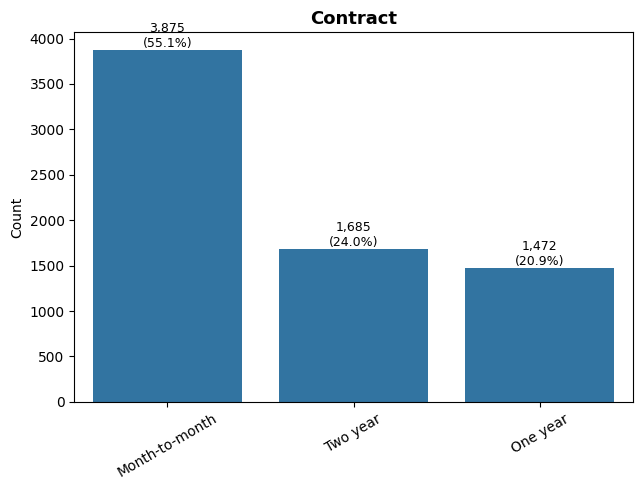

In [7]:
ordinal = ['Contract']
ds.categorical_plot(df, ordinal)

## 3_2_Nominal Features

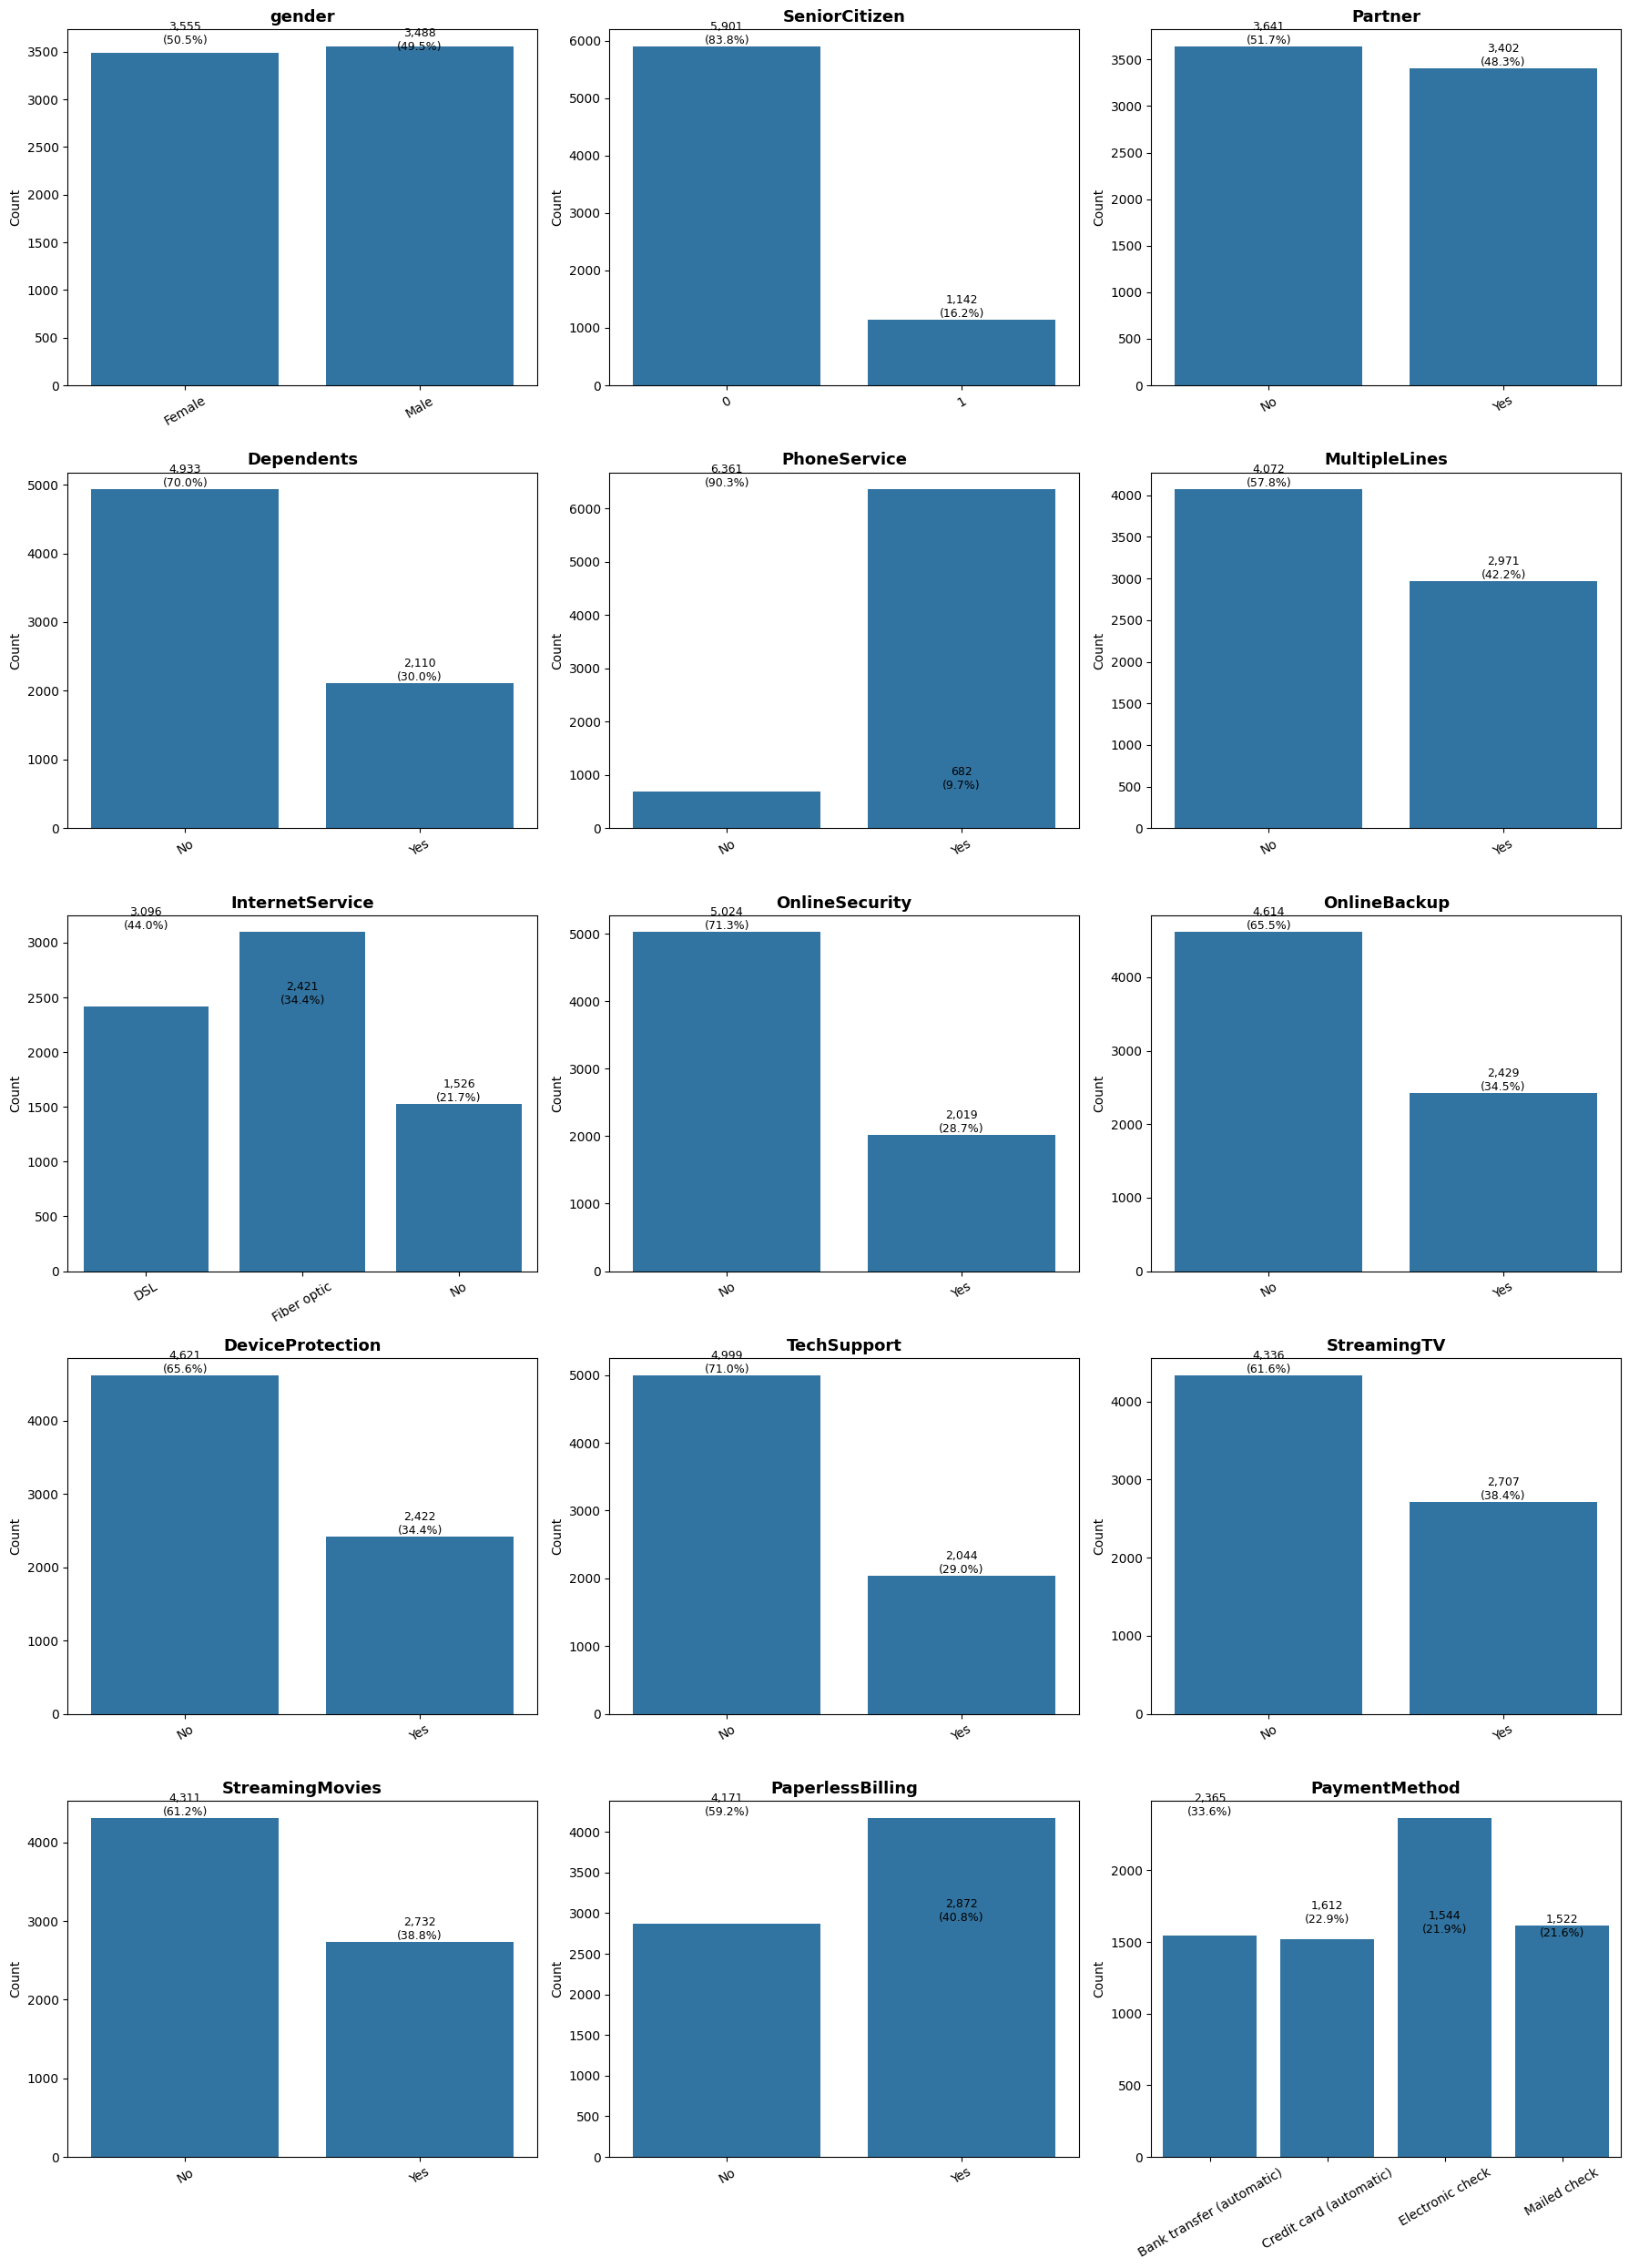

In [9]:
nominal = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'PaymentMethod']
ds.categorical_plot(df, nominal)

## 3_3_Numeric Features

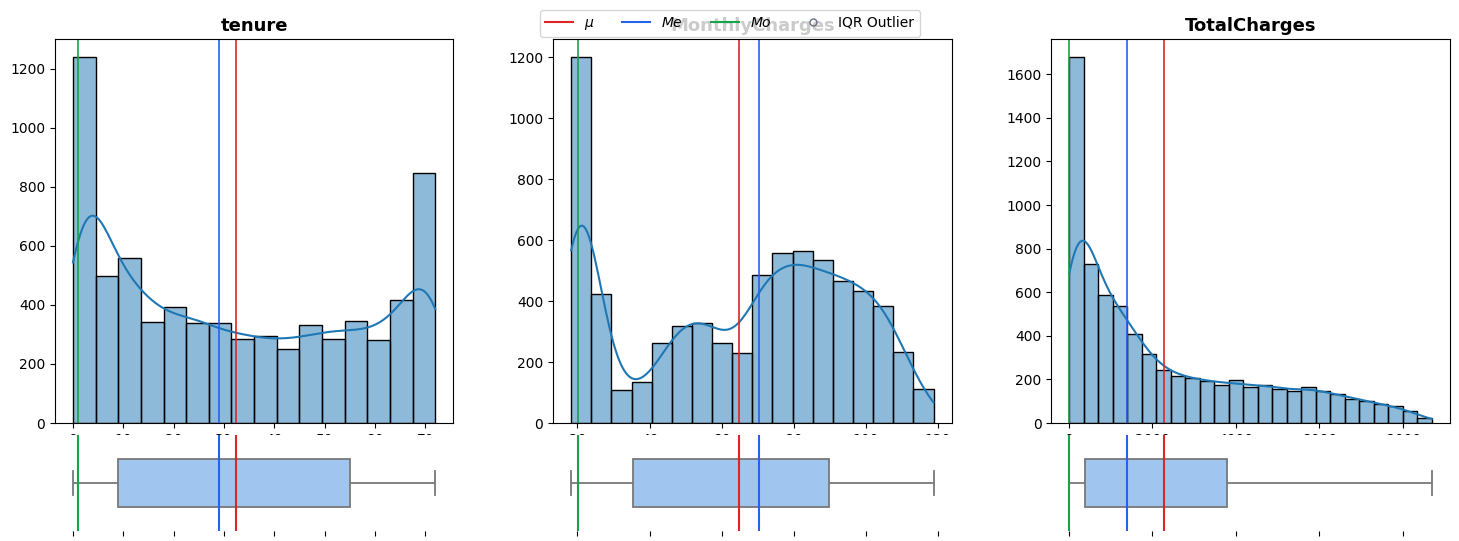

In [10]:
numeric = ['tenure', 'MonthlyCharges', 'TotalCharges']
ds.numerical_plot(df, numeric)

# 4)Modeling

In [6]:
X = df.drop(columns=['customerID', 'Churn'])
y = LabelEncoder().fit_transform(df['Churn'])

nominal = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'PaymentMethod']
ordinal = ['Contract']
ordinal_categories = [['Month-to-month', 'One year', 'Two year']]
numeric = ['tenure', 'MonthlyCharges', 'TotalCharges']

nominal_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
ordinal_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OrdinalEncoder(categories=ordinal_categories))])
numeric_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])

preprocessor = ColumnTransformer([('nominal', nominal_pipe, nominal), ('ordinal', ordinal_pipe, ordinal), ('numeric', numeric_pipe, numeric)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5)Evaluating

## 5_0_save_result Function defination

In [7]:
results = []

def save_result(name, grid):
    y_train_pred = grid.predict(X_train)
    y_test_pred = grid.predict(X_test)
    results.append({'Model': name, 'Best Parameters': grid.best_params_, 'CV Accuracy': grid.best_score_, 'Train Accuracy': accuracy_score(y_train, y_train_pred), 'Test Accuracy': accuracy_score(y_test, y_test_pred), 'Test Precision': precision_score(y_test, y_test_pred), 'Test Recall': recall_score(y_test, y_test_pred), 'Test F1': f1_score(y_test, y_test_pred)})

## 5_1_LogisticRegression

In [17]:
pipe = Pipeline([('preprocessing', preprocessor), ('pca', PCA()), ('model', LogisticRegression(max_iter=1000))])

param_grid = {'preprocessing__numeric__scaler': [StandardScaler(), MinMaxScaler()], 'pca__n_components': [.8, .9, .95, .99], 'model__C': [.01, .1, 1, 10, 100]}

grid = RandomizedSearchCV(pipe, param_grid, n_iter=10, cv=5, scoring='accuracy', n_jobs=-1, random_state=42, error_score='raise').fit(X_train, y_train)

save_result('LogisticRegression', grid)
print('Best Parameters:', grid.best_params_)
print('Best CV Accuracy:', grid.best_score_)
print('Train Accuracy:', grid.score(X_train, y_train))
print('Test Accuracy:', grid.score(X_test, y_test))

Best Parameters: {'preprocessing__numeric__scaler': StandardScaler(), 'pca__n_components': 0.99, 'model__C': 0.01}
Best CV Accuracy: 0.8010666666666666
Train Accuracy: 0.8026666666666666
Test Accuracy: 0.7953091684434968


## 5_2_KNeighborsClassifier

In [19]:
pipe = Pipeline([('preprocessing', preprocessor), ('pca', PCA()), ('model', KNeighborsClassifier())])

param_grid = {'preprocessing__numeric__scaler': [StandardScaler(), MinMaxScaler()], 'pca__n_components': [.8, .9, .95, .99], 'model__n_neighbors': [3, 5, 7, 9, 11, 15, 21], 'model__p': [1, 2]}

grid = RandomizedSearchCV(pipe, param_grid, n_iter=10, cv=5, scoring='accuracy', n_jobs=-1, random_state=42, error_score='raise').fit(X_train, y_train)

save_result('KNeighborsClassifier', grid)
print('Best Parameters:', grid.best_params_)
print('Best CV Accuracy:', grid.best_score_)
print('Train Accuracy:', grid.score(X_train, y_train))
print('Test Accuracy:', grid.score(X_test, y_test))

Best Parameters: {'preprocessing__numeric__scaler': StandardScaler(), 'pca__n_components': 0.8, 'model__p': 2, 'model__n_neighbors': 7}
Best CV Accuracy: 0.7800888888888888
Train Accuracy: 0.8270222222222222
Test Accuracy: 0.7640369580668088


## 5_3_SVC

In [20]:
pipe = Pipeline([('preprocessing', preprocessor), ('pca', PCA()), ('model', DecisionTreeClassifier(random_state=42))])

param_grid = {'preprocessing__numeric__scaler': [StandardScaler(), MinMaxScaler()], 'pca__n_components': [.8, .9, .95, .99], 'model__max_depth': [3, 5, 7, 10, 15], 'model__min_samples_split': [2, 5, 10], 'model__min_samples_leaf': [1, 2, 5]}

grid = RandomizedSearchCV(pipe, param_grid, n_iter=10, cv=5, scoring='accuracy', n_jobs=-1, random_state=42, error_score='raise').fit(X_train, y_train)

save_result('DecisionTreeClassifier', grid)
print('Best Parameters:', grid.best_params_)
print('Best CV Accuracy:', grid.best_score_)
print('Train Accuracy:', grid.score(X_train, y_train))
print('Test Accuracy:', grid.score(X_test, y_test))

Best Parameters: {'preprocessing__numeric__scaler': StandardScaler(), 'pca__n_components': 0.9, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_depth': 3}
Best CV Accuracy: 0.7900444444444445
Train Accuracy: 0.7998222222222222
Test Accuracy: 0.783226723525231


## 5_4_DecisionTreeClassifier

In [21]:
pipe = Pipeline([('preprocessing', preprocessor), ('pca', PCA()), ('model', DecisionTreeClassifier(random_state=42))])

param_grid = {'preprocessing__numeric__scaler': [StandardScaler(), MinMaxScaler()], 'pca__n_components': [.8, .9, .95, .99], 'model__max_depth': [3, 5, 7, 10, 15], 'model__min_samples_split': [2, 5, 10], 'model__min_samples_leaf': [1, 2, 5]}

grid = RandomizedSearchCV(pipe, param_grid, n_iter=10, cv=5, scoring='accuracy', n_jobs=-1, random_state=42, error_score='raise').fit(X_train, y_train)

save_result('DecisionTreeClassifier', grid)
print('Best Parameters:', grid.best_params_)
print('Best CV Accuracy:', grid.best_score_)
print('Train Accuracy:', grid.score(X_train, y_train))
print('Test Accuracy:', grid.score(X_test, y_test))

Best Parameters: {'preprocessing__numeric__scaler': StandardScaler(), 'pca__n_components': 0.9, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_depth': 3}
Best CV Accuracy: 0.7900444444444445
Train Accuracy: 0.7998222222222222
Test Accuracy: 0.783226723525231


## 5_5_RandomForestClassifier

In [22]:
pipe = Pipeline([('preprocessing', preprocessor), ('model', RandomForestClassifier(random_state=42, n_jobs=-1))])

param_grid = {'model__n_estimators': [200, 300], 'model__max_depth': [3, 5, 7, 10], 'model__min_samples_split': [5, 10, 20], 'model__min_samples_leaf': [2, 5, 10], 'model__max_samples': [.7, .8, .9]}

grid = RandomizedSearchCV(pipe, param_grid, n_iter=20, cv=5, scoring='accuracy', n_jobs=-1, random_state=42, error_score='raise').fit(X_train, y_train)

save_result('RandomForestClassifier', grid)
print('Best Parameters:', grid.best_params_)
print('Best CV Accuracy:', grid.best_score_)
print('Train Accuracy:', grid.score(X_train, y_train))
print('Test Accuracy:', grid.score(X_test, y_test))

Best Parameters: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 5, 'model__max_samples': 0.9, 'model__max_depth': 10}
Best CV Accuracy: 0.8056888888888889
Train Accuracy: 0.8481777777777778
Test Accuracy: 0.7945984363894811


## 5_6_MLPClassifier

In [23]:
pipe = Pipeline([('preprocessing', preprocessor), ('pca', PCA()), ('model', MLPClassifier(max_iter=1000, random_state=42))])

param_grid = {'preprocessing__numeric__scaler': [StandardScaler(), MinMaxScaler()], 'pca__n_components': [.9, .95], 'model__hidden_layer_sizes': [(50,), (100,)], 'model__alpha': [.001], 'model__learning_rate_init': [.001, .01]}

grid = RandomizedSearchCV(pipe, param_grid, n_iter=8, cv=5, scoring='accuracy', n_jobs=-1, random_state=42, error_score='raise').fit(X_train, y_train)

save_result('MLPClassifier', grid)
print('Best Parameters:', grid.best_params_)
print('Best CV Accuracy:', grid.best_score_)
print('Train Accuracy:', grid.score(X_train, y_train))
print('Test Accuracy:', grid.score(X_test, y_test))

Best Parameters: {'preprocessing__numeric__scaler': StandardScaler(), 'pca__n_components': 0.9, 'model__learning_rate_init': 0.001, 'model__hidden_layer_sizes': (50,), 'model__alpha': 0.001}
Best CV Accuracy: 0.7797333333333334
Train Accuracy: 0.8535111111111111
Test Accuracy: 0.7739872068230277


## 5_7_GradientBoostingClassifier

In [24]:
pipe = Pipeline([('preprocessing', preprocessor), ('model', GradientBoostingClassifier(random_state=42))])

param_grid = {'model__n_estimators': [50, 100, 150], 'model__learning_rate': [.01, .05, .1], 'model__max_depth': [1, 2, 3], 'model__min_samples_split': [5, 10, 20], 'model__min_samples_leaf': [2, 5, 10]}

grid = RandomizedSearchCV(pipe, param_grid, n_iter=20, cv=5, scoring='accuracy', n_jobs=-1, random_state=42, error_score='raise').fit(X_train, y_train)

save_result('GradientBoostingClassifier', grid)
print('Best Parameters:', grid.best_params_)
print('Best CV Accuracy:', grid.best_score_)
print('Train Accuracy:', grid.score(X_train, y_train))
print('Test Accuracy:', grid.score(X_test, y_test))

Best Parameters: {'model__n_estimators': 150, 'model__min_samples_split': 20, 'model__min_samples_leaf': 10, 'model__max_depth': 2, 'model__learning_rate': 0.1}
Best CV Accuracy: 0.8030222222222221
Train Accuracy: 0.8188444444444445
Test Accuracy: 0.7967306325515281


## 5_8_AdaBoostClassifier

In [25]:
pipe = Pipeline([('preprocessing', preprocessor), ('model', AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42), random_state=42))])

param_grid = {'model__n_estimators': [50, 100, 150], 'model__learning_rate': [.01, .05, .1, .2], 'model__estimator__max_depth': [1, 2, 3], 'model__estimator__min_samples_leaf': [1, 2, 5]}

grid = RandomizedSearchCV(pipe, param_grid, n_iter=20, cv=5, scoring='accuracy', n_jobs=-1, random_state=42, error_score='raise').fit(X_train, y_train)

save_result('AdaBoostClassifier', grid)
print('Best Parameters:', grid.best_params_)
print('Best CV Accuracy:', grid.best_score_)
print('Train Accuracy:', grid.score(X_train, y_train))
print('Test Accuracy:', grid.score(X_test, y_test))

Best Parameters: {'model__n_estimators': 150, 'model__learning_rate': 0.2, 'model__estimator__min_samples_leaf': 1, 'model__estimator__max_depth': 3}
Best CV Accuracy: 0.8016
Train Accuracy: 0.8117333333333333
Test Accuracy: 0.7960199004975125


## 5_9_GaussianNB

In [26]:
pipe = Pipeline([('preprocessing', preprocessor), ('pca', PCA()), ('model', GaussianNB())])

param_grid = {'preprocessing__numeric__scaler': [StandardScaler(), MinMaxScaler()], 'pca__n_components': [.8, .9, .95, .99], 'model__var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7]}

grid = RandomizedSearchCV(pipe, param_grid, n_iter=10, cv=5, scoring='accuracy', n_jobs=-1, random_state=42, error_score='raise').fit(X_train, y_train)

save_result('GaussianNB', grid)
print('Best Parameters:', grid.best_params_)
print('Best CV Accuracy:', grid.best_score_)
print('Train Accuracy:', grid.score(X_train, y_train))
print('Test Accuracy:', grid.score(X_test, y_test))

Best Parameters: {'preprocessing__numeric__scaler': StandardScaler(), 'pca__n_components': 0.99, 'model__var_smoothing': 1e-11}
Best CV Accuracy: 0.7864888888888889
Train Accuracy: 0.7889777777777778
Test Accuracy: 0.7683013503909026


## 5_10_Scores

In [31]:
results_df = pd.DataFrame(results)
results_df

,Model,Best Parameters,CV Accuracy,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1
0,LogisticRegression,"{'preprocessing__numeric__scaler': StandardScaler(), 'pca__n_components': 0.99, 'model__C': 0.01}",0.801067,0.802667,0.795309,0.647260,0.505348,0.567568
1,KNeighborsClassifier,"{'preprocessing__numeric__scaler': StandardScaler(), 'pca__n_components': 0.8, 'model__p': 2, 'model__n_neighbors': 7}",0.780089,0.827022,0.764037,0.558989,0.532086,0.545205
2,DecisionTreeClassifier,"{'preprocessing__numeric__scaler': StandardScaler(), 'pca__n_components': 0.9, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_depth': 3}",0.790044,0.799822,0.783227,0.637450,0.427807,0.512000
3,DecisionTreeClassifier,"{'preprocessing__numeric__scaler': StandardScaler(), 'pca__n_components': 0.9, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_depth': 3}",0.790044,0.799822,0.783227,0.637450,0.427807,0.512000
4,RandomForestClassifier,"{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 5, 'model__max_samples': 0.9, 'model__max_depth': 10}",0.805689,0.848178,0.794598,0.645051,0.505348,0.566717
5,MLPClassifier,"{'preprocessing__numeric__scaler': StandardScaler(), 'pca__n_components': 0.9, 'model__learning_rate_init': 0.001, 'model__hidden_layer_sizes': (50,), 'model__alpha': 0.001}",0.779733,0.853511,0.773987,0.584848,0.516043,0.548295
6,GradientBoostingClassifier,"{'model__n_estimators': 150, 'model__min_samples_split': 20, 'model__min_samples_leaf': 10, 'model__max_depth': 2, 'model__learning_rate': 0.1}",0.803022,0.818844,0.796731,0.643791,0.526738,0.579412
7,AdaBoostClassifier,"{'model__n_estimators': 150, 'model__learning_rate': 0.2, 'model__estimator__min_samples_leaf': 1, 'model__estimator__max_depth': 3}",0.801600,0.811733,0.796020,0.644518,0.518717,0.574815
8,GaussianNB,"{'preprocessing__numeric__scaler': StandardScaler(), 'pca__n_components': 0.99, 'model__var_smoothing': 1e-11}",0.786489,0.788978,0.768301,0.560302,0.596257,0.577720


## 5_11_Stacking

In [34]:
base_models = [
    ('lr', Pipeline([('preprocessing', preprocessor), ('pca', PCA(n_components=0.99)), ('model', LogisticRegression(C=0.01, max_iter=1000))])),
    ('gb', Pipeline([('preprocessing', preprocessor), ('model', GradientBoostingClassifier(n_estimators=150, min_samples_split=20, min_samples_leaf=10, max_depth=2, learning_rate=0.1, random_state=42))])),
    ('gnb', Pipeline([('preprocessing', preprocessor), ('pca', PCA(n_components=0.99)), ('model', GaussianNB(var_smoothing=1e-11))]))
]

stack = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression(max_iter=1000), cv=5, n_jobs=-1, stack_method='predict_proba')
stack.fit(X_train, y_train)

y_train_pred = stack.predict(X_train)
y_test_pred = stack.predict(X_test)

print('Train Accuracy:', accuracy_score(y_train, y_train_pred))
print('Test Accuracy:', accuracy_score(y_test, y_test_pred))
print('Test Precision:', precision_score(y_test, y_test_pred))
print('Test Recall:', recall_score(y_test, y_test_pred))
print('Test F1:', f1_score(y_test, y_test_pred))

Train Accuracy: 0.8144
Test Accuracy: 0.8052594171997157
Test Precision: 0.6633986928104575
Test Recall: 0.5427807486631016
Test F1: 0.5970588235294118
